In [1]:
!pip install -q timm einops

In [15]:
import os, json, random, time, math
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchvision.models as tvm
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import timm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT  = "/kaggle/input/datasets/sravyakalusani/extremetrack/ExtremeTrack"
TRAIN_JSON = os.path.join(DATA_ROOT, "ExtremeTrack_train.json")
VAL_JSON   = os.path.join(DATA_ROOT, "ExtremeTrack_val.json")
TEST_ROOT  = "/kaggle/input/datasets/sravyakalusani/test-data/Test_Data"
OUT_DIR    = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Hyper-params ───────────────────────────────────────────────────────────
CFG = dict(
    TEMPLATE_SIZE = 128,   # crop size for template (z patch)
    SEARCH_SIZE   = 256,   # crop size for search region (x patch)
    FEAT_SIZE     = 16,    # feature map size = SEARCH_SIZE / 16 (ViT stride)
    EMB_DIM       = 768,   # ViT-Base hidden dim
    LR            = 2e-4,
    EPOCHS        = 4,
    BATCH          = 8,
    SEED          = 42,
    QP_THRESH     = 20,    # pixels — QP uses 20px center-error threshold
    CONTEXT_AMOUNT= 0.5,   # SiamFC-style context padding
)

random.seed(CFG['SEED']); np.random.seed(CFG['SEED']); torch.manual_seed(CFG['SEED'])
print("Config ready")

Device: cuda
Config ready


In [3]:
def enhance_frame(img: np.ndarray) -> np.ndarray:
    dark = np.min(img, axis=2).astype(np.float32) / 255.0
    t    = 1.0 - 0.90 * dark
    t    = np.clip(t, 0.15, 1.0)[:, :, None]
    A    = np.percentile(img, 99.9, axis=(0, 1)) / 255.0
    out  = ((img.astype(np.float32) / 255.0 - A) / t + A)
    out  = np.clip(out * 255, 0, 255).astype(np.uint8)
    out  = cv2.bilateralFilter(out, d=7, sigmaColor=35, sigmaSpace=35)
    lab  = cv2.cvtColor(out, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    lab  = cv2.merge([clahe.apply(l), a, b])
    out  = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return out

_dummy = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
assert enhance_frame(_dummy).shape == (480, 640, 3)
print("Preprocessing OK")

Preprocessing OK


In [4]:
NORM = T.Normalize(mean=[0.485, 0.456, 0.406],
                   std=[0.229, 0.224, 0.225])

def to_tensor(img: np.ndarray) -> torch.Tensor:
    return NORM(torch.from_numpy(
        img.transpose(2, 0, 1)).float() / 255.0)


def crop_and_resize(img, cx, cy, size_wh, out_size):
    W, H  = img.shape[1], img.shape[0]
    s     = max(size_wh, 10)
    x1    = int(round(cx - s/2)); y1 = int(round(cy - s/2))
    x2    = x1 + int(round(s));   y2 = y1 + int(round(s))
    pad_l = max(0, -x1);  pad_t = max(0, -y1)
    pad_r = max(0, x2-W); pad_b = max(0, y2-H)
    x1 = max(x1, 0); y1 = max(y1, 0)
    x2 = min(x2, W); y2 = min(y2, H)
    crop = img[y1:y2, x1:x2]
    if pad_l + pad_t + pad_r + pad_b > 0:
        mean_val = img.mean(axis=(0, 1)).astype(np.uint8)
        crop = cv2.copyMakeBorder(crop, pad_t, pad_b, pad_l, pad_r,
                                  cv2.BORDER_CONSTANT,
                                  value=mean_val.tolist())
    crop = cv2.resize(crop, (out_size, out_size))
    return crop, out_size / s


class Sequence:
    def __init__(self, name, obj, is_train=True):
        self.name      = name
        self.video     = obj["video_dir"]
        self.imgs      = obj["img_names"]
        self.gt        = obj["gt_rect"]
        self.condition = "HAZY" if "Haze" in name else "RAIN"
        self.is_train  = is_train

    def _split_folder(self):
        if self.condition == "RAIN":
            return "Train_set" if self.is_train else "Val_set"
        return "Train_Set" if self.is_train else "Val_set"

    def get_frame(self, i):
        img_name = os.path.basename(self.imgs[i])
        split    = self._split_folder()
        for path in [
            os.path.join(DATA_ROOT, self.condition, split,
                         self.video, img_name),
            os.path.join(DATA_ROOT, self.condition, split,
                         self.video, "img", img_name),
        ]:
            if os.path.exists(path):
                img = cv2.imread(path)
                if img is not None:
                    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return None


class TrackPairDataset(Dataset):
    def __init__(self, json_path, is_train=True, augment=True):
        with open(json_path) as f:
            data = json.load(f)
        self.seqs    = [Sequence(k, v, is_train) for k, v in data.items()]
        self.augment = augment
        self.pairs   = self._build_pairs()

    def _build_pairs(self):
        pairs = []
        for seq in self.seqs:
            n = len(seq.imgs)
            if n < 2:
                continue
            for i in range(n - 1):
                gap = max(1, min(10, n - i - 1))
                j   = min(i + random.randint(1, gap), n - 1)
                pairs.append((seq, i, j))
        return pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        seq, ti, si = self.pairs[idx]
        z_img = seq.get_frame(ti)
        x_img = seq.get_frame(si)

        if z_img is None or x_img is None:
            z = torch.zeros(3, CFG['TEMPLATE_SIZE'], CFG['TEMPLATE_SIZE'])
            x = torch.zeros(3, CFG['SEARCH_SIZE'],   CFG['SEARCH_SIZE'])
            return z, x, torch.zeros(4)

        z_img = enhance_frame(z_img)
        x_img = enhance_frame(x_img)

        zx, zy, zw, zh = seq.gt[ti]
        sx, sy, sw, sh = seq.gt[si]
        zcx, zcy = zx + zw/2, zy + zh/2
        scx, scy = sx + sw/2, sy + sh/2

        z_sz            = math.sqrt(
            (zw + CFG['CONTEXT_AMOUNT']*(zw+zh)) *
            (zh + CFG['CONTEXT_AMOUNT']*(zw+zh)))
        z_crop, _       = crop_and_resize(z_img, zcx, zcy,
                                          z_sz, CFG['TEMPLATE_SIZE'])
        x_sz            = z_sz * (CFG['SEARCH_SIZE'] / CFG['TEMPLATE_SIZE'])
        x_crop, x_scale = crop_and_resize(x_img, scx, scy,
                                          x_sz, CFG['SEARCH_SIZE'])

        half = CFG['SEARCH_SIZE'] / 2
        gt   = torch.tensor([0.0, 0.0,
                              (sw * x_scale) / half,
                              (sh * x_scale) / half],
                             dtype=torch.float32)

        if self.augment and random.random() > 0.5:
            z_crop = cv2.flip(z_crop, 1)
            x_crop = cv2.flip(x_crop, 1)
            gt[0]  = -gt[0]

        return to_tensor(z_crop), to_tensor(x_crop), gt


with open(TRAIN_JSON) as f:
    _td = json.load(f)
print(f"Train sequences: {len(_td)}")
_ds = TrackPairDataset(TRAIN_JSON, is_train=True)
print(f"Train pairs: {len(_ds)}")
_z, _x, _gt = _ds[0]
print(f"z: {_z.shape}, x: {_x.shape}, gt: {_gt}")

Train sequences: 128
Train pairs: 53655
z: torch.Size([3, 128, 128]), x: torch.Size([3, 256, 256]), gt: tensor([-0.0000, 0.0000, 0.4464, 0.5550])


In [5]:
class OSTrackHead(nn.Module):
    def __init__(self, dim=768, feat_size=16):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(embed_dim=dim,
                                                 num_heads=8,
                                                 batch_first=True)
        self.ln  = nn.LayerNorm(dim)
        self.reg = nn.Sequential(
            nn.Linear(dim, 256), nn.GELU(),
            nn.Linear(256,  64), nn.GELU(),
            nn.Linear(64,    4), nn.Tanh()
        )
        self.cls = nn.Sequential(
            nn.Linear(dim, 128), nn.GELU(),
            nn.Linear(128,   1), nn.Sigmoid()
        )

    def forward(self, z_feat, x_feat):
        fused, _ = self.cross_attn(query=z_feat,
                                    key=x_feat, value=x_feat)
        fused    = self.ln(fused)
        pooled   = fused.mean(dim=1)
        return self.reg(pooled), self.cls(pooled)


class OSTrackModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            img_size=CFG['SEARCH_SIZE'],
            num_classes=0,
            global_pool=""
        )
        dim       = self.backbone.embed_dim
        self.head = OSTrackHead(dim=dim, feat_size=CFG['FEAT_SIZE'])
        for i, blk in enumerate(self.backbone.blocks):
            for p in blk.parameters():
                p.requires_grad = (i >= 6)

    def extract(self, img):
        S = CFG['SEARCH_SIZE']
        if img.shape[-1] != S or img.shape[-2] != S:
            img = F.interpolate(img, size=(S, S),
                                mode='bilinear', align_corners=False)
        tokens   = self.backbone.forward_features(img)
        expected = (S // 16) ** 2
        if tokens.shape[1] == expected + 1:
            tokens = tokens[:, 1:, :]
        return tokens

    def forward(self, z, x):
        return self.head(self.extract(z), self.extract(x))


_model = OSTrackModel().to(DEVICE)
_z_t   = torch.randn(2, 3, CFG['TEMPLATE_SIZE'], CFG['TEMPLATE_SIZE']).to(DEVICE)
_x_t   = torch.randn(2, 3, CFG['SEARCH_SIZE'],   CFG['SEARCH_SIZE']).to(DEVICE)
with torch.no_grad():
    _b, _s = _model(_z_t, _x_t)
print(f"Box: {_b.shape}  Score: {_s.shape}")
del _z_t, _x_t, _b, _s
print("OSTrack model ready")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Box: torch.Size([2, 4])  Score: torch.Size([2, 1])
OSTrack model ready


In [6]:
def iou_loss(pred_box, gt_box):
    half = CFG['SEARCH_SIZE'] / 2
    p    = pred_box * half
    g    = gt_box   * half
    px1  = p[:,0]-p[:,2]/2; py1 = p[:,1]-p[:,3]/2
    px2  = p[:,0]+p[:,2]/2; py2 = p[:,1]+p[:,3]/2
    gx1  = g[:,0]-g[:,2]/2; gy1 = g[:,1]-g[:,3]/2
    gx2  = g[:,0]+g[:,2]/2; gy2 = g[:,1]+g[:,3]/2
    inter = ((torch.min(px2,gx2)-torch.max(px1,gx1)).clamp(0) *
             (torch.min(py2,gy2)-torch.max(py1,gy1)).clamp(0))
    area_p = (px2-px1).clamp(0)*(py2-py1).clamp(0)
    area_g = (gx2-gx1).clamp(0)*(gy2-gy1).clamp(0)
    union  = area_p + area_g - inter + 1e-7
    iou    = inter / union
    enc    = ((torch.max(px2,gx2)-torch.min(px1,gx1)).clamp(0) *
              (torch.max(py2,gy2)-torch.min(py1,gy1)).clamp(0) + 1e-7)
    giou   = iou - (enc - union) / enc
    return (1 - giou).mean()

def l1_loss(pred_box, gt_box):
    return F.l1_loss(pred_box, gt_box)

def compute_qp(pred_boxes, gt_boxes, threshold=20):
    success = 0
    for p, g in zip(pred_boxes, gt_boxes):
        pcx = p[0]+p[2]/2; pcy = p[1]+p[3]/2
        gcx = g[0]+g[2]/2; gcy = g[1]+g[3]/2
        if math.sqrt((pcx-gcx)**2+(pcy-gcy)**2) < threshold:
            success += 1
    return success / max(len(pred_boxes), 1)

print("Loss + QP ready")

Loss + QP ready


Train batches: 6706
Val   batches: 17112


Epoch 1:   7%|▋         | 502/6706 [07:08<1:29:16,  1.16it/s]

  Mid-save batch 500 → 721.4MB ✓


Epoch 1:  15%|█▍        | 1001/6706 [14:22<1:52:19,  1.18s/it]

  Mid-save batch 1000 → 721.4MB ✓


...

  Mid-save batch 6000 → 721.4MB ✓


Epoch 4:  97%|█████████▋| 6502/6706 [1:26:45<02:49,  1.20it/s]

  Mid-save batch 6500 → 721.4MB ✓


Epoch 4: 100%|██████████| 6706/6706 [1:29:22<00:00,  1.25it/s]


Epoch 4/4  loss=0.3690  lr=1.00e-06  time=5364s  saved=721.4MB ✓

Training COMPLETE


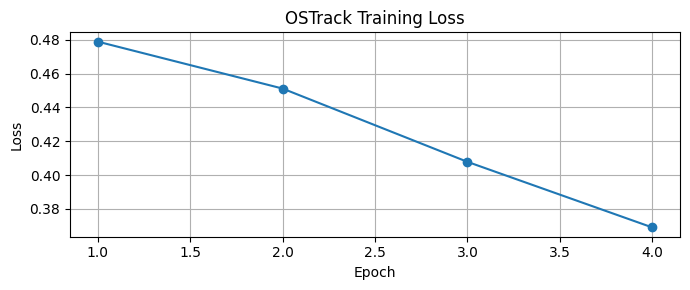

In [7]:
def train_one_epoch(model, loader, optimizer, scaler, epoch, ckpt_path):
    model.train()
    total_loss = 0.0
    for batch_idx, (z, x, gt) in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}")):
        z, x, gt = z.to(DEVICE), x.to(DEVICE), gt.to(DEVICE)
        with torch.amp.autocast('cuda'):
            pred_box, pred_score = model(z, x)
            loss = iou_loss(pred_box, gt) + 2.0 * l1_loss(pred_box, gt)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        if batch_idx % 500 == 0 and batch_idx > 0:
            torch.save({
                "epoch":     epoch,
                "batch":     batch_idx,
                "model":     model.state_dict(),
                "optimizer": optimizer.state_dict(),
            }, ckpt_path)
            sz = round(os.path.getsize(ckpt_path)/1e6, 1)
            print(f"  Mid-save batch {batch_idx} → {sz}MB ✓")
    return total_loss / len(loader)


train_ds     = TrackPairDataset(TRAIN_JSON, is_train=True,  augment=True)
val_ds       = TrackPairDataset(VAL_JSON,   is_train=False, augment=False)
train_loader = DataLoader(train_ds, batch_size=CFG['BATCH'],
                          shuffle=True,  num_workers=2,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=1,
                          shuffle=False, num_workers=2,
                          pin_memory=True)
print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")

model     = OSTrackModel().to(DEVICE)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['LR'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['EPOCHS'], eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda')

ckpt_path    = os.path.join(OUT_DIR, "ostrack_best.pth")
train_losses = []

for epoch in range(CFG['EPOCHS']):
    t0         = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer,
                                 scaler, epoch, ckpt_path)
    scheduler.step()
    train_losses.append(train_loss)
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "loss": train_loss,
    }, ckpt_path)
    sz = round(os.path.getsize(ckpt_path)/1e6, 1)
    print(f"Epoch {epoch+1}/{CFG['EPOCHS']}  loss={train_loss:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}  "
          f"time={time.time()-t0:.0f}s  saved={sz}MB ✓")

print("\nTraining COMPLETE")
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("OSTrack Training Loss")
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), dpi=100)
plt.show()

In [8]:
class OSTrackerInference:
    def __init__(self, model):
        self.model = model
        self.model.eval()

    def init(self, img: np.ndarray, box):
        x, y, w, h = box
        self._cx   = x + w/2
        self._cy   = y + h/2
        self._w    = w
        self._h    = h
        z_sz       = math.sqrt(
            (w + CFG['CONTEXT_AMOUNT']*(w+h)) *
            (h + CFG['CONTEXT_AMOUNT']*(w+h)))
        self._z_sz = z_sz
        z_crop, _  = crop_and_resize(img, self._cx, self._cy,
                                     z_sz, CFG['TEMPLATE_SIZE'])
        self._z_tensor = to_tensor(z_crop).unsqueeze(0).to(DEVICE)

    def update(self, img: np.ndarray):
        x_sz            = self._z_sz * (CFG['SEARCH_SIZE'] /
                                         CFG['TEMPLATE_SIZE'])
        x_crop, x_scale = crop_and_resize(img, self._cx, self._cy,
                                          x_sz, CFG['SEARCH_SIZE'])
        x_tensor = to_tensor(x_crop).unsqueeze(0).to(DEVICE)
        with torch.no_grad(), torch.amp.autocast('cuda'):
            pred_box, _ = self.model(self._z_tensor, x_tensor)
        half   = CFG['SEARCH_SIZE'] / 2
        pred   = pred_box[0].cpu().numpy() * half
        H, W   = img.shape[:2]
        new_cx = float(np.clip(self._cx + pred[0]/x_scale, 0, W))
        new_cy = float(np.clip(self._cy + pred[1]/x_scale, 0, H))
        new_w  = float(np.clip(abs(pred[2])/x_scale, 10, W))
        new_h  = float(np.clip(abs(pred[3])/x_scale, 10, H))
        self._cx = new_cx
        self._cy = new_cy
        self._w  = new_w
        self._h  = new_h
        return [new_cx - new_w/2, new_cy - new_h/2, new_w, new_h]

print("Inference tracker ready")

Inference tracker ready


In [9]:
def evaluate_on_val(model):
    with open(VAL_JSON) as f:
        val_data = json.load(f)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    seq_qps = []
    for name, obj in tqdm(val_data.items(), desc="Validating"):
        seq = Sequence(name, obj, is_train=False)
        if len(seq.imgs) == 0:
            continue
        tracker    = OSTrackerInference(model)
        pred_boxes = []
        for i in range(len(seq.imgs)):
            frame = seq.get_frame(i)
            if frame is None:
                pred_boxes.append(pred_boxes[-1] if pred_boxes
                                  else [0,0,10,10])
                continue
            frame = enhance_frame(frame)
            if i == 0:
                init_box = obj.get("init_rect", seq.gt[0])
                tracker.init(frame, init_box)
                pred_boxes.append(list(init_box))
            else:
                pred_boxes.append(tracker.update(frame))
        qp = compute_qp(pred_boxes[1:], seq.gt[1:])
        seq_qps.append(qp)
        print(f"  {name:35s}  QP={qp:.3f}")
    mean_qp = float(np.mean(seq_qps)) if seq_qps else 0.0
    print(f"\n=== Mean Validation QP: {mean_qp:.4f} ===")
    return mean_qp

val_qp = evaluate_on_val(model)

Validating:   5%|▌         | 1/20 [00:09<03:05,  9.77s/it]

  Bird2_Haze                           QP=0.061


Validating:  10%|█         | 2/20 [01:09<11:43, 39.06s/it]

  BlurCar2_Haze                        QP=0.053


Validating:  15%|█▌        | 3/20 [02:08<13:36, 48.02s/it]

...

  drone_Rain                           QP=0.000


Validating:  95%|█████████▌| 19/20 [31:32<02:45, 165.57s/it]

  Human2_Rain                          QP=0.014


Validating: 100%|██████████| 20/20 [32:25<00:00, 97.28s/it] 

  Panda_Rain                           QP=0.071

=== Mean Validation QP: 0.0763 ===


In [17]:
def run_test_and_submit(model):
    results = {}
    for condition in ["Hazy_Test_Set", "Rain_Test_set"]:
        cond_path = os.path.join(TEST_ROOT, condition)
        if not os.path.exists(cond_path):
            print(f"Skipping missing: {cond_path}")
            continue
        for seq_name in sorted(os.listdir(cond_path)):
            seq_path = os.path.join(cond_path, seq_name)
            if not os.path.isdir(seq_path):
                continue
            img_dir = os.path.join(seq_path, "img")
            if not os.path.exists(img_dir):
                img_dir = seq_path
            images = sorted([
                os.path.join(img_dir, f)
                for f in os.listdir(img_dir)
                if f.lower().endswith((".jpg",".jpeg",".png"))
            ])
            if not images:
                continue
            init_box = None
            for anno in ["groundtruth.txt","init.txt","anno.txt"]:
                anno_path = os.path.join(seq_path, anno)
                if os.path.exists(anno_path):
                    with open(anno_path) as f:
                        line = f.readline().strip().replace("\t",",")
                        vals = [float(v) for v in line.split(",") if v]
                        if len(vals) == 4:
                            init_box = vals
                    break
            if init_box is None:
                frame0   = cv2.imread(images[0])
                h0, w0   = frame0.shape[:2]
                iw, ih   = w0*0.10, h0*0.10
                init_box = [w0/2-iw/2, h0/2-ih/2, iw, ih]
                print(f"WARNING: no init box for {seq_name}")
            tracker = OSTrackerInference(model)
            preds   = []
            print(f"Processing {seq_name} ({len(images)} frames)")
            for i, img_path in enumerate(tqdm(images, leave=False)):
                frame = cv2.imread(img_path)
                if frame is None:
                    preds.append(preds[-1] if preds else init_box)
                    continue
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = enhance_frame(frame)
                if i == 0:
                    tracker.init(frame, init_box)
                    preds.append([float(v) for v in init_box])
                else:
                    preds.append(tracker.update(frame))
            results[seq_name] = {
                "pred_rect": [[round(v,2) for v in box] for box in preds]
            }
    sub_path = os.path.join(OUT_DIR, "ExtremeTrack_submission.json")
    with open(sub_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nSubmission saved: {sub_path}")
    print(f"Total sequences: {len(results)}")

run_test_and_submit(model)

Processing BlurCar1 (742 frames)


Processing Car24 (3059 frames)


Processing Dog2 (267 frames)


Processing Elephant (222 frames)


Processing NOOSA_SURF (270 frames)


...

Processing Woman (597 frames)


Processing dat_12 (203 frames)


Processing dat_2 (255 frames)


Processing dat_32 (220 frames)



Submission saved: /kaggle/working/ExtremeTrack_submission.json
Total sequences: 20
